In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("mtcars.csv")
df

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


# Exercise 1

# 1. Write a user defined function ‘myFnLinReg(x,y)’ to perform Simple Linear Regression given one predictor attribute and one response attribute. The function should return the coefficients of the straight line. 

In [19]:
import numpy as np

def myFnLinReg(x, y):
    x = np.array(x)
    y = np.array(y)
    
    # means
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # slope b1
    b1 = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
    
    # intercept b0
    b0 = y_mean - b1*x_mean
    
    return b0, b1


# 2. Use mtcars data set and consider the attributes mpg and weight. Split data into train and test sets (80 %,20%). Put training data set to ‘myFnLinReg(x,y)’ to build a linear regression model to predict mpg given the weight of the car. 

In [26]:
x = df['wt'].values   # car weight
y = df['mpg'].values  # miles per gallon

# Train-test split (80-20)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Use our function on training data
b0, b1 = myFnLinReg(x_train, y_train)
print("Intercept (b0):", b0)
print("Slope (b1):", b1)

Intercept (b0): 36.93731031351841
Slope (b1): -5.336941400557081


# 3. What is the mpg of a car, whose weight is 5.5? 

In [15]:
pred_5_5 = b0 + b1 * 5.5
print(f"Predicted MPG for weight 5.5: {pred_5_5:.2f}")


Predicted MPG for weight 5.5: 7.58


# 4. Compute and print accuracy measures such as RMSE and R2  for the test set.  

In [17]:
y_pred_test = b0 + b1 * x_test
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R^2: {r2:.4f}")


Test RMSE: 3.5321
Test R^2: 0.6880


# 5. Apply the stochastic gradient descent and mini batch gradient descent algorithms to enhance the accuracy and visualize the cost function.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Cost function
def compute_cost(x, y, b0, b1):
    n = len(y)
    predictions = b0 + b1*x
    return np.sum((y - predictions)**2) / n

# Stochastic Gradient Descent
def stochastic_gradient_descent(x, y, lr=0.01, epochs=100):
    b0, b1 = 0.0, 0.0
    n = len(y)
    cost_history = []

    for epoch in range(epochs):
        for i in range(n):
            xi = x[i]
            yi = y[i]
            pred = b0 + b1*xi
            error = yi - pred
            
            # update
            b0 = b0 + lr * error
            b1 = b1 + lr * error * xi
        
        cost = compute_cost(x, y, b0, b1)
        cost_history.append(cost)
    
    return b0, b1, cost_history

# Mini-batch Gradient Descent
def mini_batch_gradient_descent(x, y, lr=0.01, epochs=100, batch_size=5):
    b0, b1 = 0.0, 0.0
    n = len(y)
    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        x_shuffled, y_shuffled = x[indices], y[indices]

        for i in range(0, n, batch_size):
            xb = x_shuffled[i:i+batch_size]
            yb = y_shuffled[i:i+batch_size]

            pred = b0 + b1*xb
            error = yb - pred

            b0 = b0 + lr * np.mean(error)
            b1 = b1 + lr * np.mean(error * xb)

        cost = compute_cost(x, y, b0, b1)
        cost_history.append(cost)
    
    return b0, b1, cost_history



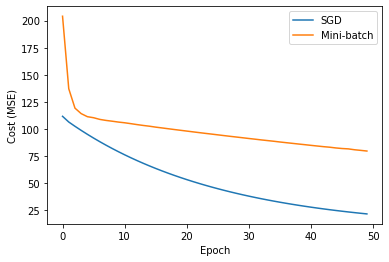

In [31]:

x_train = x_train.reshape(-1)  # make sure it's 1D
b0_sgd, b1_sgd, cost_sgd = stochastic_gradient_descent(x_train, y_train, lr=0.01, epochs=50)
b0_mb, b1_mb, cost_mb = mini_batch_gradient_descent(x_train, y_train, lr=0.01, epochs=50, batch_size=5)

# Plot cost functions
plt.plot(cost_sgd, label="SGD")
plt.plot(cost_mb, label="Mini-batch")
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.legend()
plt.show()


# Exercise 2

In [34]:
import pandas as pd
import numpy as np

df = pd.read_csv("Boston.csv")
df


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


# 1. Use the boston.csv dataset and determine the best 5 features to predict ‘MEDV’.  

In [35]:
corr_matrix = df.corr()
top5_features = corr_matrix['medv'].abs().sort_values(ascending=False)[1:6]
print("Top 5 features:\n", top5_features)


Top 5 features:
 lstat      0.737663
rm         0.695360
ptratio    0.507787
indus      0.483725
tax        0.468536
Name: medv, dtype: float64


# 2. Using sklearn.linear_model, find the multiple regression model for the boston.csv dataset using the best 3 features. 

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


X = df[['lstat', 'rm', 'ptratio']]
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Feature order:", X.columns.tolist())


Intercept: 14.58809926157107
Coefficients: [-0.56712588  4.93311836 -0.86709475]
Feature order: ['lstat', 'rm', 'ptratio']


# 3. Find the accuracy of the model using appropriate metrics using 80, 20 split for training and test. 

In [38]:

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


RMSE: 5.21
R²: 0.63
